# MediaPipe FaceLandmarker

In [31]:
# %pip install --quiet mediapipe opencv-python numpy pandas tqdm matplotlib

In [32]:
from pathlib import Path
import urllib.request

# Layout (relative to the notebook's working directory):
#   facial_paralysis/
#   ├── livelinkface_data/<take>/<video>.mov     <- inputs (untouched)
#   └── mediapipe_out/
#       ├── _models/face_landmarker.task         <- shared model
#       ├── per_video_meta.csv                   <- top-level batch manifest
#       └── <take>/                              <- SELF-CONTAINED per-take folder
#           ├── landmarks.csv                    (frame, point_idx, x, y, z)
#           ├── blendshapes.csv                  (frame, blendshape, score)
#           ├── blendshapes_wide.csv             (frame, timestamp_ms, 52 cols)
#           ├── transform_matrices.npy           shape (n_frames, 4, 4)
#           └── <stem>_landmarks.mp4             annotated video
INPUT_ROOT  = Path("livelinkface_data")
OUTPUT_ROOT = Path("mediapipe_out")
MODEL_DIR   = OUTPUT_ROOT / "_models"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

META_CSV   = OUTPUT_ROOT / "per_video_meta.csv"

MODEL_URL  = "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task"
MODEL_PATH = MODEL_DIR / "face_landmarker.task"
if not MODEL_PATH.exists():
    print("downloading model:", MODEL_PATH)
    urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)
print("model ready :", MODEL_PATH, MODEL_PATH.stat().st_size, "bytes")
print("input root  :", INPUT_ROOT.resolve())
print("output root :", OUTPUT_ROOT.resolve())

downloading model: mediapipe_out/_models/face_landmarker.task
model ready : mediapipe_out/_models/face_landmarker.task 3758596 bytes
input root  : /Users/qiu.ziyue/Library/CloudStorage/OneDrive-MayoClinic/ziyue/facial_paralysis/data/livelinkface_data
output root : /Users/qiu.ziyue/Library/CloudStorage/OneDrive-MayoClinic/ziyue/facial_paralysis/data/mediapipe_out


In [33]:
# Discover all videos under INPUT_ROOT.
# Rules:
#   - take == immediate subdirectory of INPUT_ROOT
#   - look for *.mov / *.mp4 directly inside the take folder
#   - if zero videos -> skip with a note (fallback)
#   - if one video   -> output goes to <take>/
#   - if multiple    -> process ALL of them, output goes to <take>/<stem>/
VIDEO_EXTS = {".mov", ".mp4", ".m4v"}

def discover_videos(root: Path):
    """Returns list of (slot_id, take_name, video_path).
    `slot_id` is the relative output folder name; equals take_name for the
    single-video case, otherwise '<take>/<stem>'.
    """
    items, skipped, warnings = [], [], []
    if not root.exists():
        raise FileNotFoundError(f"INPUT_ROOT does not exist: {root.resolve()}")
    for take_dir in sorted(p for p in root.iterdir() if p.is_dir()):
        vids = sorted(p for p in take_dir.iterdir()
                      if p.is_file() and p.suffix.lower() in VIDEO_EXTS)
        if not vids:
            skipped.append((take_dir.name, "no video file"))
            continue
        if len(vids) == 1:
            items.append((take_dir.name, take_dir.name, vids[0]))
        else:
            warnings.append((take_dir.name,
                             f"{len(vids)} videos, processing all into <take>/<stem>/"))
            for v in vids:
                items.append((f"{take_dir.name}/{v.stem}", take_dir.name, v))
    return items, skipped, warnings


all_items, skipped, warnings = discover_videos(INPUT_ROOT)
print(f"found {len(all_items)} videos to process, {len(skipped)} folders skipped, {len(warnings)} warnings")
for slot_id, take_name, vid in all_items:
    print("  +", slot_id, "->", vid.name)
for name, reason in skipped:
    print("  - SKIP", name, "(" + reason + ")")
for name, reason in warnings:
    print("  ! WARN", name, "(" + reason + ")")

MAX_ITEMS = None  # set to int to limit, or None for all
items_to_run = all_items if MAX_ITEMS is None else all_items[:MAX_ITEMS]
print("\nwill process this run:", [s for s, _, _ in items_to_run])

found 15 videos to process, 8 folders skipped, 0 warnings
  + 20260109_MySlate_6 -> MySlate_6_iPhone.mov
  + 20260203_FACES006 -> MySlate_10_iPhone.mov
  + 20260219_FACES014 -> MySlate_13_iPhone.mov
  + 20260305_FACES018 -> MySlate_14_iPhone.mov
  + 20260305_MySlate_14 -> MySlate_14_iPhone.mov
  + 20260313_FACES004 -> MySlate_19_iPhone.mov
  + 20260313_FACES019 -> MySlate_16_iPhone.mov
  + 20260313_FACES020 -> MySlate_17_iPhone.mov
  + 20260313_FACES021 -> MySlate_21_iPhone.mov
  + 20260313_MySlate_22 -> MySlate_22_iPhone.mov
  + 20260313_MySlate_23 -> MySlate_23_iPhone.mov
  + 20260313_MySlate_25 -> MySlate_25_iPhone.mov
  + 20260402_FACES024 -> MySlate_27_iPhone.mov
  + 20260410_MySlate_28 -> MySlate_28_iPhone.mov
  + 20260414_MySlate_29 -> MySlate_29_iPhone.mov
  - SKIP 20260109_MySlate_2 (no video file)
  - SKIP 20260109_MySlate_4 (no video file)
  - SKIP 20260112_FACES016 (no video file)
  - SKIP 20260129_FACES002 (no video file)
  - SKIP 20260219_FACES017 (no video file)
  - SKIP

In [34]:
import cv2
import numpy as np

# Draw the 478 raw points.
#   0-467   -> face mesh (skin / lips / eyes / brows / nose / oval), small green
#   468-477 -> iris (5L + 5R), slightly bigger red dot
# We benchmarked a NumPy-vectorized version and it was actually no faster than
# plain cv2.circle on this stack, so we keep the simple loop.
MESH_COLOR = (0, 255, 0)
IRIS_COLOR = (0, 0, 255)
IRIS_START = 468

def draw_landmarks_on_frame(bgr_frame: np.ndarray, face_landmarks_list) -> np.ndarray:
    annotated = bgr_frame.copy()
    h, w = annotated.shape[:2]
    for face_landmarks in face_landmarks_list:
        for i, lm in enumerate(face_landmarks):
            cx, cy = int(lm.x * w), int(lm.y * h)
            if i >= IRIS_START:
                cv2.circle(annotated, (cx, cy), 2, IRIS_COLOR, -1, cv2.LINE_AA)
            else:
                cv2.circle(annotated, (cx, cy), 1, MESH_COLOR, -1, cv2.LINE_AA)
    return annotated

In [ ]:
import json
import math
import threading
import time
import mediapipe as mp
import pandas as pd
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

# Speed / resume / display knobs -------------------------------------
WRITE_ANNOTATED   = True     # set False to skip the annotated mp4 (~1.4x faster)
FORCE_REPROCESS   = False    # set True to redo every video regardless of done.json
SHOW_PROGRESS     = True     # periodic progress reporter (one consolidated line per tick)
PROGRESS_INTERVAL = 5.0      # seconds between progress snapshots
CSV_FLOAT_FORMAT  = "%.4f"   # 4 decimals: sub-pixel for landmarks, sub-noise for blendshapes
# --------------------------------------------------------------------
# Note: GPU/Metal delegate not used. The Apple-Silicon mediapipe wheel crashes
# at inference ("unsupported ImageFrame format") if Delegate.GPU is set, so we
# stay on CPU + XNNPACK. Speed comes from the multi-thread batch loop.

_BaseOptions = mp_python.BaseOptions
DONE_MARKER = "done.json"
REQUIRED_FILES = ["landmarks.csv", "blendshapes.csv",
                  "blendshapes_wide.csv", "transform_matrices.npy"]


# --------------------------------------------------------------------
# Progress reporter
# Worker threads write (frame_idx, total) into a shared dict for their slot.
# A daemon thread reads the dict every PROGRESS_INTERVAL seconds and prints
# ONE consolidated line covering all live videos. This replaces per-frame
# tqdm spam (which got captured as hundreds of stream-output lines by
# nbconvert) with a steady, readable status feed that still shows per-video
# progress while running in parallel.
# --------------------------------------------------------------------
class _ProgressReporter:
    def __init__(self):
        self._state = {}    # slot_id -> (current_frame, total_frames)
        self._lock = threading.Lock()
        self._stop = threading.Event()
        self._thread = None
        self._t0 = 0.0

    def update(self, slot_id, current, total):
        with self._lock:
            self._state[slot_id] = (current, total)

    def remove(self, slot_id):
        with self._lock:
            self._state.pop(slot_id, None)

    def _format_line(self):
        with self._lock:
            items = sorted(self._state.items())
        if not items:
            return None
        parts = []
        for sid, (cur, total) in items:
            # Compact label: drop YYYYMMDD_ prefix and any nested path
            label = sid.split("/")[-1]
            if len(label) > 9 and label[:8].isdigit() and label[8] == "_":
                label = label[9:]
            pct = int(100 * cur / total) if total > 0 else 0
            parts.append(f"{label}:{cur}/{total}({pct:>3d}%)")
        elapsed = time.perf_counter() - self._t0
        return f"  [{elapsed:5.1f}s active={len(items)}] " + " | ".join(parts)

    def _run(self):
        while not self._stop.wait(PROGRESS_INTERVAL):
            line = self._format_line()
            if line:
                print(line, flush=True)

    def start(self):
        if not SHOW_PROGRESS:
            return
        self._t0 = time.perf_counter()
        self._stop.clear()
        self._thread = threading.Thread(target=self._run, daemon=True)
        self._thread.start()

    def stop(self):
        self._stop.set()
        if self._thread is not None:
            self._thread.join(timeout=1.0)
            self._thread = None


_PROGRESS = _ProgressReporter()


def _is_already_done(take_out: Path) -> bool:
    """A take is 'done' only if done.json AND all required data files exist.
    The marker is written ONLY after every output file is fully on disk, so
    an interrupted run leaves no marker -> the next batch run reprocesses it.
    """
    if not (take_out / DONE_MARKER).exists():
        return False
    return all((take_out / f).exists() for f in REQUIRED_FILES)


def _load_done_meta(take_out: Path):
    try:
        return json.loads((take_out / DONE_MARKER).read_text())
    except Exception:
        return None


def make_landmarker():
    """Fresh CPU landmarker per video — VIDEO mode timestamps are per-stream."""
    return mp_vision.FaceLandmarker.create_from_options(
        mp_vision.FaceLandmarkerOptions(
            base_options=_BaseOptions(model_asset_path=str(MODEL_PATH)),
            running_mode=mp_vision.RunningMode.VIDEO,
            num_faces=1,
            output_face_blendshapes=True,
            output_facial_transformation_matrixes=True,
            min_face_detection_confidence=0.5,
            min_face_presence_confidence=0.5,
            min_tracking_confidence=0.5,
        )
    )


def process_video(slot_id: str, video_path: Path):
    """Run MediaPipe on one video and write outputs into mediapipe_out/<slot_id>/.
    Returns a meta dict. If resumed from a prior successful run, meta has
    resumed=True and elapsed_s=0.

    Fallbacks:
      - VideoCapture cannot open      -> raises RuntimeError
      - fps / width / height invalid  -> raises RuntimeError
      - read() fails on first frame   -> raises RuntimeError, mp4 deleted
      - read() truncates mid-video    -> writes what we got + records partial=True
      - any uncaught exception        -> no done.json written; reruns will redo it
    """
    take_out = OUTPUT_ROOT / slot_id

    # Resume short-circuit
    if not FORCE_REPROCESS and _is_already_done(take_out):
        cached = _load_done_meta(take_out)
        if cached is not None:
            cached = dict(cached)
            cached["resumed"] = True
            cached["elapsed_s"] = 0.0
            return cached

    take_out.mkdir(parents=True, exist_ok=True)
    # If a prior crash left a stale marker that no longer matches the files,
    # remove it now so we don't accidentally trust it later.
    stale = take_out / DONE_MARKER
    if stale.exists():
        try:
            stale.unlink()
        except Exception:
            pass

    landmarks_csv    = take_out / "landmarks.csv"
    blendshapes_csv  = take_out / "blendshapes.csv"
    blendshapes_wide = take_out / "blendshapes_wide.csv"
    transform_npy    = take_out / "transform_matrices.npy"
    annotated_path   = take_out / f"{video_path.stem}_landmarks.mp4"

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"cannot open video: {video_path}")

    t0 = time.perf_counter()
    try:
        fps          = cap.get(cv2.CAP_PROP_FPS)
        width        = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height       = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        if not (math.isfinite(fps) and fps > 0):
            raise RuntimeError(f"invalid fps={fps} (header probably corrupt)")
        if width <= 0 or height <= 0:
            raise RuntimeError(f"invalid frame size {width}x{height}")

        writer = None
        if WRITE_ANNOTATED:
            fourcc = cv2.VideoWriter_fourcc(*"mp4v")
            writer = cv2.VideoWriter(str(annotated_path), fourcc, fps, (width, height))
            if not writer.isOpened():
                raise RuntimeError(f"cannot open writer for {annotated_path}")

        landmarker = make_landmarker()

        lm_rows, bs_rows, wide_rows, mats = [], [], [], []
        n_face_frames = 0
        frame_idx = 0
        # Register the slot so the reporter knows we exist even before frame 1
        _PROGRESS.update(slot_id, 0, total_frames)
        try:
            while True:
                ok, bgr = cap.read()
                if not ok:
                    break

                rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
                mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
                ts_ms = int(round(frame_idx * 1000.0 / fps))
                result = landmarker.detect_for_video(mp_image, ts_ms)

                fl_list = result.face_landmarks
                bs_list = result.face_blendshapes
                tm_list = result.facial_transformation_matrixes

                if fl_list:
                    n_face_frames += 1
                    for i, lm in enumerate(fl_list[0]):
                        lm_rows.append((frame_idx, i, lm.x, lm.y, lm.z))

                wide_row = {"frame": frame_idx, "timestamp_ms": ts_ms}
                if bs_list:
                    for cat in bs_list[0]:
                        bs_rows.append((frame_idx, cat.category_name, float(cat.score)))
                        wide_row[cat.category_name] = float(cat.score)
                wide_rows.append(wide_row)

                if tm_list:
                    mats.append(np.asarray(tm_list[0], dtype=np.float32))
                else:
                    mats.append(np.full((4, 4), np.nan, dtype=np.float32))

                if writer is not None:
                    writer.write(draw_landmarks_on_frame(bgr, fl_list))
                frame_idx += 1
                _PROGRESS.update(slot_id, frame_idx, total_frames)
        finally:
            if writer is not None:
                writer.release()
            landmarker.close()

        if frame_idx == 0:
            try:
                annotated_path.unlink(missing_ok=True)
            except Exception:
                pass
            raise RuntimeError(f"no readable frames in {video_path} (likely corrupt)")

        partial = (total_frames > 0 and frame_idx < total_frames)
        elapsed = time.perf_counter() - t0
        rate = frame_idx / elapsed if elapsed > 0 else float("nan")

        # Write all data files BEFORE the done.json marker.
        # float_format="%.4f" trims float CSV columns to 4 decimals:
        #   - landmarks x/y/z (normalized) -> ~1/7 pixel on 720x1280 (~0.7mm on a 200px face)
        #   - blendshape scores (0-1)      -> 0.0001 is well below the model's noise floor
        # int columns (frame, point_idx, timestamp_ms) are unaffected.
        pd.DataFrame(lm_rows, columns=["frame", "point_idx", "x", "y", "z"]).to_csv(
            landmarks_csv, index=False, float_format=CSV_FLOAT_FORMAT)
        pd.DataFrame(bs_rows, columns=["frame", "blendshape", "score"]).to_csv(
            blendshapes_csv, index=False, float_format=CSV_FLOAT_FORMAT)

        df_wide = pd.DataFrame(wide_rows)
        if not df_wide.empty:
            cols = ["frame", "timestamp_ms"] + sorted(
                c for c in df_wide.columns if c not in {"frame", "timestamp_ms"}
            )
            df_wide = df_wide[cols]
        df_wide.to_csv(blendshapes_wide, index=False, float_format=CSV_FLOAT_FORMAT)

        # transform_matrices.npy stays binary float32 — no text precision issue
        # and rotation matrices need full float32 for stable angle decomposition.
        np.save(transform_npy, np.stack(mats, axis=0) if mats else np.empty((0, 4, 4)))

        meta = {
            "slot_id": slot_id,
            "video_path": str(video_path),
            "fps": fps,
            "width": width,
            "height": height,
            "n_frames_header": total_frames,
            "n_frames_read": frame_idx,
            "n_face_frames": n_face_frames,
            "partial": partial,
            "elapsed_s": round(elapsed, 2),
            "fps_proc": round(rate, 1),
            "wrote_annotated": WRITE_ANNOTATED,
            "out_dir": str(take_out),
            "resumed": False,
        }
        # Marker is the LAST thing written — its presence == complete + trustworthy.
        (take_out / DONE_MARKER).write_text(json.dumps(meta, indent=2))
        return meta
    finally:
        cap.release()
        # Always drop this slot from the progress dict so it disappears from
        # the next status snapshot (whether we succeeded or raised).
        _PROGRESS.remove(slot_id)

In [36]:
import os
from concurrent.futures import ThreadPoolExecutor, as_completed

# Parallelism knob ---------------------------------------------------
# MediaPipe inference and cv2 I/O release the GIL, so threads give real
# speedup across multiple videos. 1 = sequential (safest), >1 = parallel.
NUM_WORKERS = min(4, max(1, (os.cpu_count() or 2) - 1))
# --------------------------------------------------------------------

def _run_one(item):
    slot_id, take_name, video_path = item
    try:
        meta = process_video(slot_id, video_path)
        meta["take"] = take_name
        return slot_id, meta, None
    except Exception as e:
        return slot_id, {"slot_id": slot_id, "take": take_name,
                         "video_path": str(video_path), "error": str(e),
                         "resumed": False}, e


def _format_line(meta, err):
    slot_id = meta.get("slot_id", "?")
    if err is not None:
        return f"! {slot_id} FAILED: {err}"
    if meta.get("resumed"):
        return (f"= {slot_id}: SKIPPED (already done; "
                f"{meta.get('n_frames_read','?')} frames cached)")
    note = " (PARTIAL)" if meta.get("partial") else ""
    return (f"+ {slot_id}: {meta['n_frames_read']}/{meta['n_frames_header']} frames{note}, "
            f"face on {meta['n_face_frames']}, "
            f"{meta['elapsed_s']}s ({meta['fps_proc']} fps)")


metas = []
t_batch = time.perf_counter()
print(f"{'parallel' if NUM_WORKERS > 1 else 'sequential'} mode "
      f"(NUM_WORKERS={NUM_WORKERS}, {len(items_to_run)} videos, "
      f"FORCE_REPROCESS={FORCE_REPROCESS}, SHOW_PROGRESS={SHOW_PROGRESS})\n")

# Periodic progress reporter prints one consolidated status line every
# PROGRESS_INTERVAL seconds while workers are running.
_PROGRESS.start()
try:
    if NUM_WORKERS <= 1 or len(items_to_run) <= 1:
        for it in items_to_run:
            slot_id, meta, err = _run_one(it)
            print(_format_line(meta, err), flush=True)
            metas.append(meta)
    else:
        with ThreadPoolExecutor(max_workers=NUM_WORKERS) as pool:
            futures = [pool.submit(_run_one, it) for it in items_to_run]
            for f in as_completed(futures):
                slot_id, meta, err = f.result()
                print(_format_line(meta, err), flush=True)
                metas.append(meta)
finally:
    _PROGRESS.stop()

# Sort manifest by slot_id for deterministic ordering
metas.sort(key=lambda m: m.get("slot_id", ""))
wall = time.perf_counter() - t_batch
done = [m for m in metas if "error" not in m]
processed = [m for m in done if not m.get("resumed")]
resumed   = [m for m in done if m.get("resumed")]
total_frames_processed = sum(m.get("n_frames_read", 0) for m in processed)
print(f"\nbatch wall time: {wall:.1f}s | "
      f"processed: {len(processed)} ({total_frames_processed} frames) | "
      f"resumed: {len(resumed)} | "
      f"failed: {len(metas) - len(done)}")

pd.DataFrame(metas).to_csv(META_CSV, index=False)
print("manifest:", META_CSV)

parallel mode (NUM_WORKERS=4, 15 videos, FORCE_REPROCESS=False, SHOW_PROGRESS=True)



W0000 00:00:1779378799.890573 2270628 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
W0000 00:00:1779378799.890905 2270631 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
W0000 00:00:1779378799.890589 2270629 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
W0000 00:00:1779378799.890766 2270630 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1779378799.927728 2270628 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2 Pro
I0000 00:00:1779378799.927869 2270629 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2 Pro
I0000 00:00:1779378799.928370 2270631 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2 Pro
I0000 00:00:1779378799.928741 2270630 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2 Pro
W0000 00:00:1779

  [  2.0s active=4] MySlate_6:75/5536(  1%) | FACES006:67/7376(  0%) | FACES014:69/7140(  0%) | FACES018:67/7038(  0%)
  [  4.0s active=4] MySlate_6:163/5536(  2%) | FACES006:151/7376(  2%) | FACES014:152/7140(  2%) | FACES018:153/7038(  2%)
  [  6.0s active=4] MySlate_6:250/5536(  4%) | FACES006:227/7376(  3%) | FACES014:228/7140(  3%) | FACES018:236/7038(  3%)
  [  8.0s active=4] MySlate_6:338/5536(  6%) | FACES006:305/7376(  4%) | FACES014:309/7140(  4%) | FACES018:318/7038(  4%)
  [ 10.0s active=4] MySlate_6:432/5536(  7%) | FACES006:383/7376(  5%) | FACES014:390/7140(  5%) | FACES018:402/7038(  5%)
  [ 12.0s active=4] MySlate_6:524/5536(  9%) | FACES006:465/7376(  6%) | FACES014:471/7140(  6%) | FACES018:485/7038(  6%)
  [ 14.0s active=4] MySlate_6:629/5536( 11%) | FACES006:561/7376(  7%) | FACES014:565/7140(  7%) | FACES018:584/7038(  8%)
  [ 16.0s active=4] MySlate_6:727/5536( 13%) | FACES006:647/7376(  8%) | FACES014:652/7140(  9%) | FACES018:675/7038(  9%)
  [ 18.0s active=4] 

E0000 00:00:1779378917.905309 2270632 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid for uploading until: 2026-05-21T12:09:20.339086-04:00
=== Source Location Trace: ===
wireless/android/play/playlog/cplusplus/portable_clearcut_uploader.cc:180


  [118.6s active=4] MySlate_6:5536/5536(100%) | FACES006:5071/7376( 68%) | FACES014:5172/7140( 72%) | FACES018:5325/7038( 75%)


...

  [597.3s active=2] MySlate_28:6923/7175( 96%) | MySlate_29:5856/8529( 68%)
  [599.3s active=2] MySlate_28:7040/7175( 98%) | MySlate_29:5974/8529( 70%)
  [601.3s active=2] MySlate_28:7157/7175( 99%) | MySlate_29:6099/8529( 71%)


E0000 00:00:1779379401.472212 2277159 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid for uploading until: 2026-05-21T12:16:43.751917-04:00
=== Source Location Trace: ===
wireless/android/play/playlog/cplusplus/portable_clearcut_uploader.cc:180


  [603.3s active=2] MySlate_28:7175/7175(100%) | MySlate_29:6126/8529( 71%)
  [605.4s active=2] MySlate_28:7175/7175(100%) | MySlate_29:6143/8529( 72%)
  [607.4s active=2] MySlate_28:7175/7175(100%) | MySlate_29:6157/8529( 72%)
  [609.4s active=2] MySlate_28:7175/7175(100%) | MySlate_29:6173/8529( 72%)
  [611.4s active=2] MySlate_28:7175/7175(100%) | MySlate_29:6190/8529( 72%)
+ 20260410_MySlate_28: 7175/7175 frames, face on 7175, 158.03s (45.4 fps)
  [613.4s active=1] MySlate_29:6275/8529( 73%)
  [615.5s active=1] MySlate_29:6393/8529( 74%)
  [617.5s active=1] MySlate_29:6519/8529( 76%)
  [619.5s active=1] MySlate_29:6645/8529( 77%)
  [621.5s active=1] MySlate_29:6772/8529( 79%)
  [623.5s active=1] MySlate_29:6897/8529( 80%)
  [625.5s active=1] MySlate_29:7021/8529( 82%)
  [627.5s active=1] MySlate_29:7142/8529( 83%)
  [629.5s active=1] MySlate_29:7268/8529( 85%)
  [631.5s active=1] MySlate_29:7395/8529( 86%)
  [633.5s active=1] MySlate_29:7523/8529( 88%)
  [635.5s active=1] MySlate_2

E0000 00:00:1779379449.493214 2277704 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid for uploading until: 2026-05-21T12:17:15.094638-04:00
=== Source Location Trace: ===
wireless/android/play/playlog/cplusplus/portable_clearcut_uploader.cc:180


  [651.5s active=1] MySlate_29:8529/8529(100%)
  [653.6s active=1] MySlate_29:8529/8529(100%)
  [655.6s active=1] MySlate_29:8529/8529(100%)
  [657.6s active=1] MySlate_29:8529/8529(100%)
  [659.6s active=1] MySlate_29:8529/8529(100%)
+ 20260414_MySlate_29: 8529/8529 frames, face on 8529, 174.75s (48.8 fps)

batch wall time: 661.5s | processed: 15 (87988 frames) | resumed: 0 | failed: 0
manifest: mediapipe_out/per_video_meta.csv


In [37]:
print("== per_video_meta.csv ==")
print(pd.read_csv(META_CSV))

print("\n== mediapipe_out/ tree ==")
for p in sorted(OUTPUT_ROOT.rglob("*")):
    if p.is_dir():
        print(f"  {p}/")
    else:
        size = p.stat().st_size
        print(f"  {p}  ({size:>10,} B)")

# spot-check the first processed take
first = next((m for m in metas if 'error' not in m), None)
if first:
    take_dir = Path(first["out_dir"])
    print(f"\n== sanity check on {first['take']} ==")
    df_lm = pd.read_csv(take_dir / "landmarks.csv")
    print("landmarks.csv :", df_lm.shape, "; expected rows =", first['n_frames_read'] * 478)
    print(df_lm.head())
    df_w = pd.read_csv(take_dir / "blendshapes_wide.csv")
    print("\nblendshapes_wide.csv :", df_w.shape, "; first 4 expression columns")
    print(df_w[["frame", "timestamp_ms", "jawOpen", "mouthSmileLeft", "mouthSmileRight"]].head())
    arr = np.load(take_dir / "transform_matrices.npy")
    print("\ntransform_matrices.npy :", arr.shape)

== per_video_meta.csv ==
                slot_id                                         video_path  \
0    20260109_MySlate_6  livelinkface_data/20260109_MySlate_6/MySlate_6...   
1     20260203_FACES006  livelinkface_data/20260203_FACES006/MySlate_10...   
2     20260219_FACES014  livelinkface_data/20260219_FACES014/MySlate_13...   
3     20260305_FACES018  livelinkface_data/20260305_FACES018/MySlate_14...   
4   20260305_MySlate_14  livelinkface_data/20260305_MySlate_14/MySlate_...   
5     20260313_FACES004  livelinkface_data/20260313_FACES004/MySlate_19...   
6     20260313_FACES019  livelinkface_data/20260313_FACES019/MySlate_16...   
7     20260313_FACES020  livelinkface_data/20260313_FACES020/MySlate_17...   
8     20260313_FACES021  livelinkface_data/20260313_FACES021/MySlate_21...   
9   20260313_MySlate_22  livelinkface_data/20260313_MySlate_22/MySlate_...   
10  20260313_MySlate_23  livelinkface_data/20260313_MySlate_23/MySlate_...   
11  20260313_MySlate_25  livelinkface_d

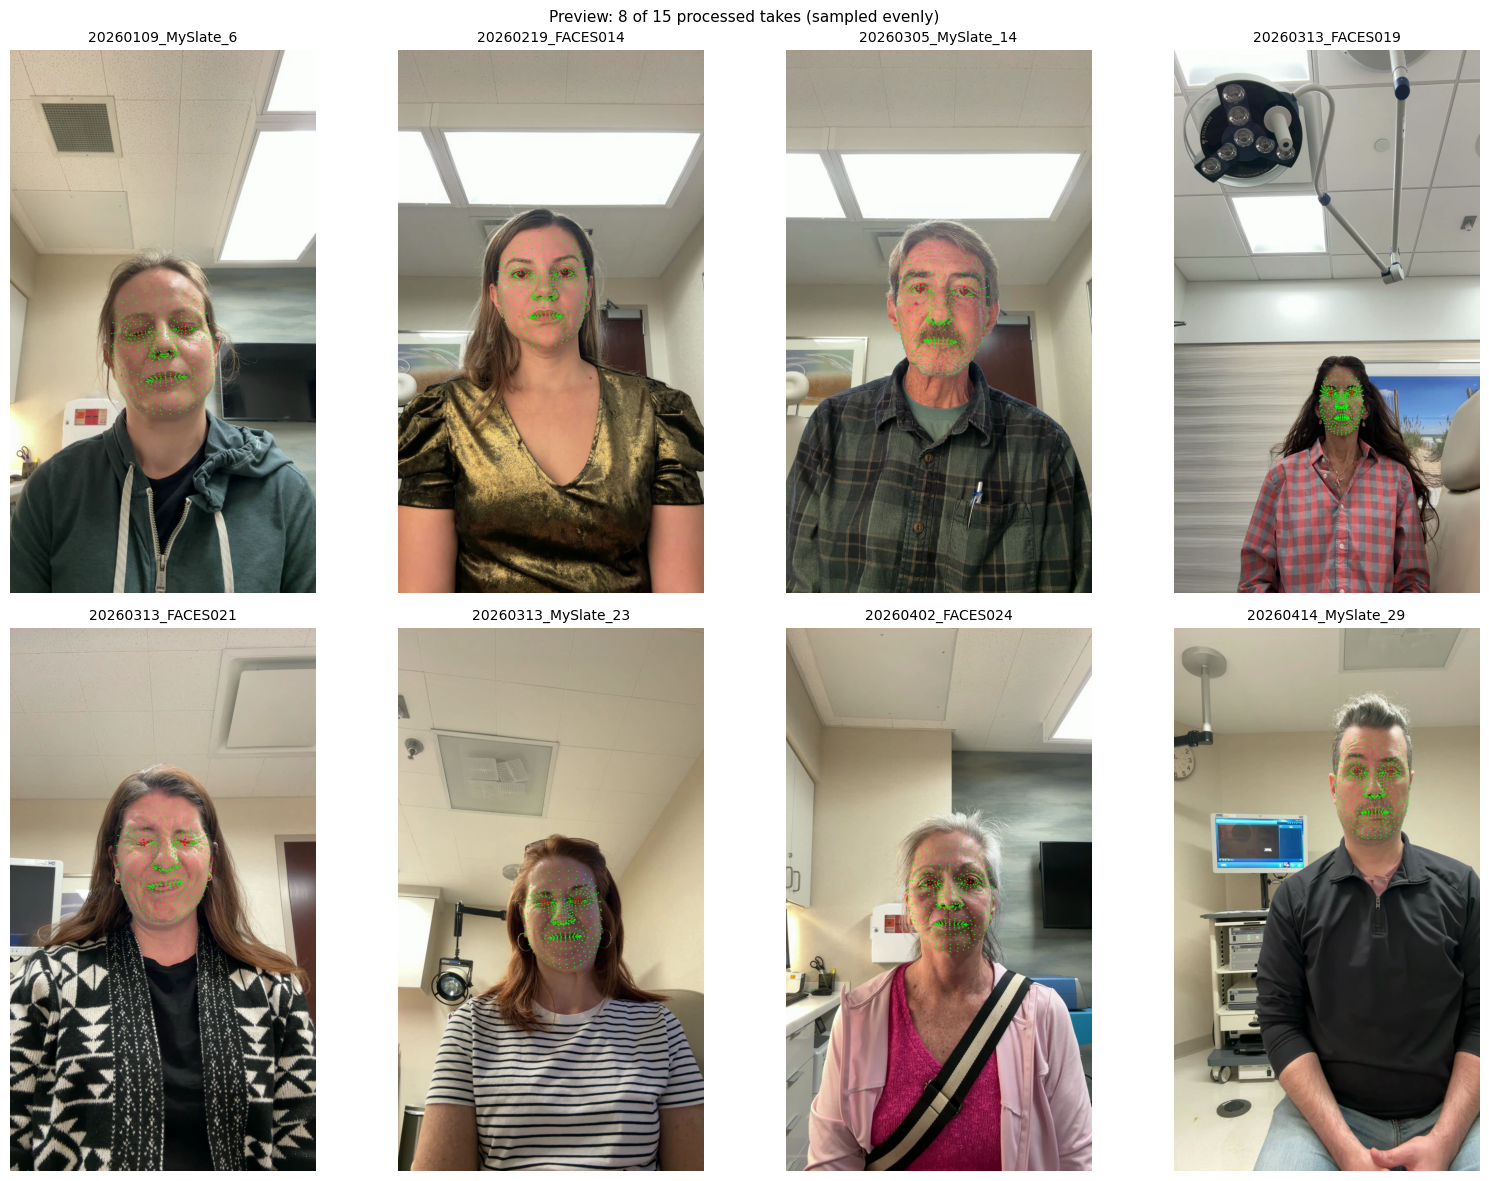

In [38]:
import math
import matplotlib.pyplot as plt

# Show up to 8 takes in at most 2 rows × 4 cols. With many takes we can't fit
# them all, so we sample evenly (first, last, plus 6 in between) so the picks
# still cover the spread of the batch.
PREVIEW_MAX  = 8
PREVIEW_COLS = 4

processed = [m for m in metas if "error" not in m]
if processed:
    if len(processed) <= PREVIEW_MAX:
        pick = processed
    else:
        # Evenly sampled indices including first and last.
        idxs = [round(i * (len(processed) - 1) / (PREVIEW_MAX - 1))
                for i in range(PREVIEW_MAX)]
        pick = [processed[i] for i in idxs]

    n_cols = min(PREVIEW_COLS, len(pick))
    n_rows = math.ceil(len(pick) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 6 * n_rows))

    # Normalize axes to a flat list regardless of grid shape
    if n_rows == 1 and n_cols == 1:
        axes_flat = [axes]
    else:
        axes_flat = list(axes.flat) if hasattr(axes, "flat") else list(axes)

    for ax, meta in zip(axes_flat, pick):
        take_dir = Path(meta["out_dir"])
        mp4 = next(take_dir.glob("*_landmarks.mp4"), None)
        if mp4 is None:
            ax.set_title(f"{meta['slot_id']}\n(no mp4)", fontsize=9)
            ax.axis("off")
            continue
        cap = cv2.VideoCapture(str(mp4))
        cap.set(cv2.CAP_PROP_POS_FRAMES, max(0, meta["n_frames_read"] // 2))
        ok, mid = cap.read()
        cap.release()
        if ok:
            ax.imshow(cv2.cvtColor(mid, cv2.COLOR_BGR2RGB))
            ax.set_title(meta["slot_id"], fontsize=10)
        ax.axis("off")

    # Hide unused grid cells (when last row isn't full)
    for ax in axes_flat[len(pick):]:
        ax.axis("off")

    if len(processed) > PREVIEW_MAX:
        fig.suptitle(
            f"Preview: {len(pick)} of {len(processed)} processed takes (sampled evenly)",
            fontsize=11,
        )
    plt.tight_layout()
    plt.show()